# Decision Tree — Breast Cancer Classification



In [2]:

# Set up
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             confusion_matrix, roc_curve, auc)
sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams["figure.dpi"] = 110
%matplotlib inline


# Load Wisconsin Breast Cancer dataset 
# 30 cell-nucleus image features; target 0=malignant, 1=benign

cancer = load_breast_cancer(as_frame=True)
df = cancer.frame
X = cancer.data
y = cancer.target
feature_names = list(cancer.feature_names)
print(f"Dataset shape: {df.shape}  |  Classes: {np.bincount(y).tolist()} "
      "(0=malignant, 1=benign)")
print(f"Missing values: {df.isna().sum().sum()}")


# Preprocessing — stratified split + StandardScaler (fit on train only)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y)
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)
print(f"Train: {X_train.shape[0]} | Test: {X_test.shape[0]}")


Dataset shape: (569, 31)  |  Classes: [212, 357] (0=malignant, 1=benign)
Missing values: 0
Train: 455 | Test: 114


Test  accuracy : 0.9123  |  precision: 0.9559
Recall         : 0.9028  |  F1      : 0.9286
Test  ROC-AUC  : 0.9157
CV    ROC-AUC  : 0.9179 ± 0.0201


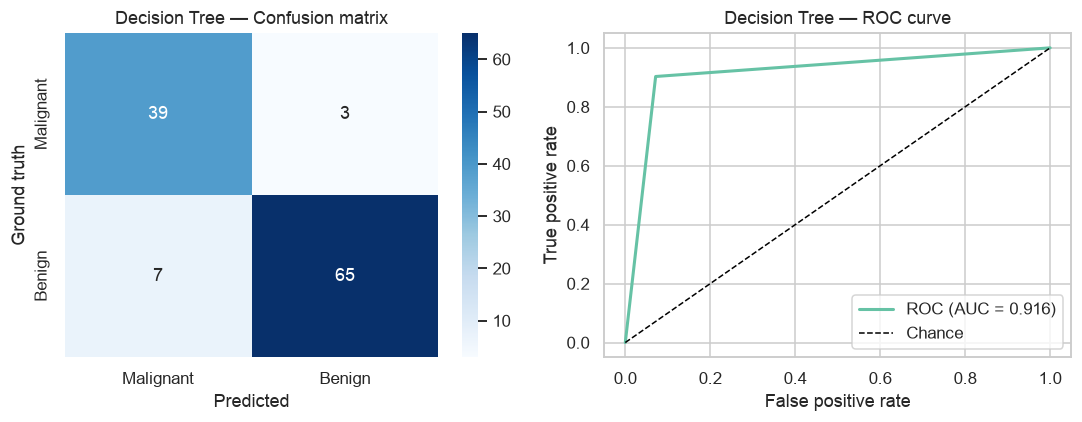

In [3]:

# Train Decision Tree & evaluate

from sklearn.tree import DecisionTreeClassifier
model = DecisionTreeClassifier(random_state=42)
model.fit(X_train_sc, y_train)
y_pred = model.predict(X_test_sc)
y_prob = model.predict_proba(X_test_sc)[:, 1]

acc  = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec  = recall_score(y_test, y_pred)
f1   = f1_score(y_test, y_pred)
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)
cv_scores = cross_val_score(model, X_train_sc, y_train,
                            cv=StratifiedKFold(5, shuffle=True, random_state=42),
                            scoring="roc_auc")

print(f"Test  accuracy : {acc:.4f}  |  precision: {prec:.4f}")
print(f"Recall         : {rec:.4f}  |  F1      : {f1:.4f}")
print(f"Test  ROC-AUC  : {roc_auc:.4f}")
print(f"CV    ROC-AUC  : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[0],
            xticklabels=["Malignant", "Benign"], yticklabels=["Malignant", "Benign"])
axes[0].set_title("Decision Tree — Confusion matrix")
axes[0].set_xlabel("Predicted"); axes[0].set_ylabel("Ground truth")
axes[1].plot(fpr, tpr, lw=2, label=f"ROC (AUC = {roc_auc:.3f})")
axes[1].plot([0, 1], [0, 1], "k--", lw=1, label="Chance")
axes[1].set_xlabel("False positive rate"); axes[1].set_ylabel("True positive rate")
axes[1].set_title("Decision Tree — ROC curve")
axes[1].legend(loc="lower right")
plt.tight_layout(); plt.show()


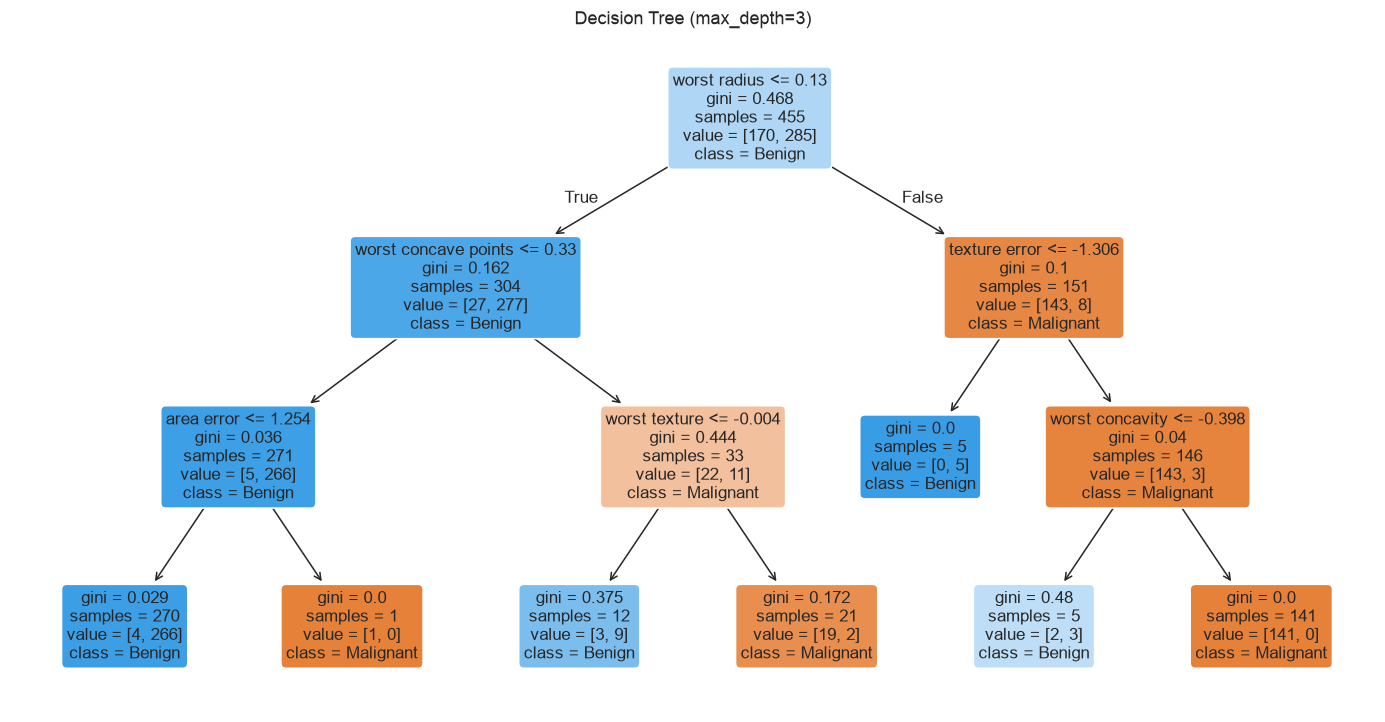

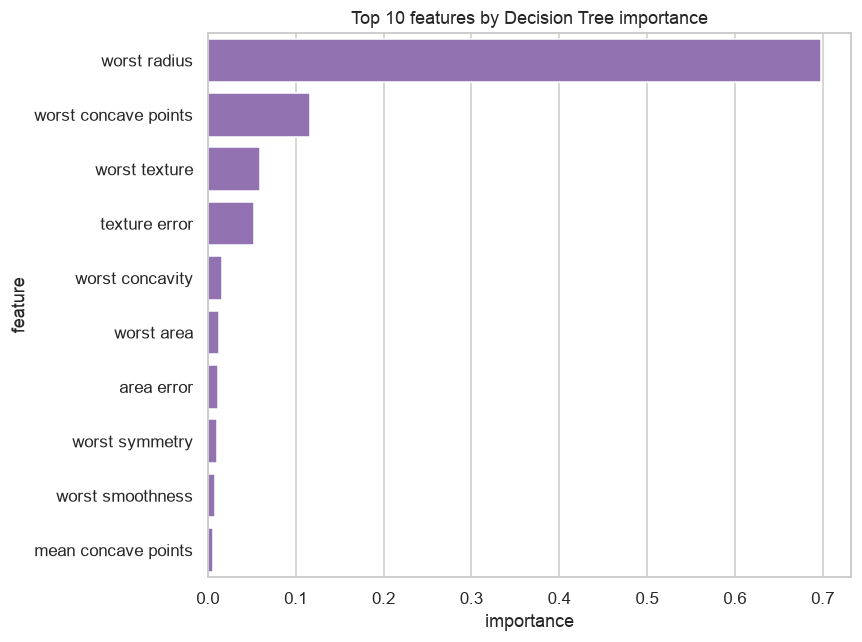

In [ ]:
# Decision tree visualization & feature importance implementation

from sklearn.tree import plot_tree

# Visualize 3 depth decision tree
dt_vis = DecisionTreeClassifier(max_depth=3, random_state=42)
dt_vis.fit(X_train_sc, y_train)

plt.figure(figsize=(16, 8))
plot_tree(dt_vis, filled=True, rounded=True,
          feature_names=feature_names,
          class_names=["Malignant", "Benign"])
plt.title("Decision Tree (max_depth=3)")
plt.show()

# feature importance implementation
imp = pd.DataFrame({"feature": feature_names,
                    "importance": model.feature_importances_}
                   ).sort_values("importance", ascending=False)
plt.figure(figsize=(8, 6))
sns.barplot(data=imp.head(10), x="importance", y="feature", color="#9467bd")
plt.title("Top 10 features by Decision Tree importance")
plt.tight_layout(); plt.show()